# Model B - R(2+1)D-18 on Kaggle (GPU)

Self-contained, no `src/` imports. Trains the pretrained R(2+1)D-18 with:
  1. A learning-rate sweep run to (near-)saturation with early stopping
     - addresses the reviewer's note that a short fixed-epoch sweep favours
     rates that start fast rather than the best rate for the full run.
  2. A final training run, also to saturation.

Before running:
  - Settings > Accelerator > GPU (P100 or T4).
  - Add your clips Kaggle Dataset as Input (same one used for Model A).

## Step 1 - Check GPU

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - enable GPU!")

CUDA available: True
GPU: Tesla T4


## Step 2 - Locate the clips under /kaggle/input

In [2]:
import glob, os

CANDIDATES = glob.glob("/kaggle/input/**/train/_metadata.csv", recursive=True)
assert CANDIDATES, "Could not find train/_metadata.csv under /kaggle/input. Add the dataset as Input."
TRAIN_META = CANDIDATES[0]
TEST_META = TRAIN_META.replace("/train/", "/test/")
CLIP_ROOT = os.path.dirname(os.path.dirname(TRAIN_META))
print("Train metadata:", TRAIN_META)
print("Test metadata: ", TEST_META)
print("Clip root:     ", CLIP_ROOT)

Train metadata: /kaggle/input/datasets/lanamatic/ipn-hand-clips/processed/train/_metadata.csv
Test metadata:  /kaggle/input/datasets/lanamatic/ipn-hand-clips/processed/test/_metadata.csv
Clip root:      /kaggle/input/datasets/lanamatic/ipn-hand-clips/processed


## Step 3 - Constants, dataset, model (inline)

In [3]:
import numpy as np
import pandas as pd
import cv2
import time
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
import torchvision.models.video as video_models
from sklearn.model_selection import train_test_split

NUM_CLASSES = 13
GESTURE_NAMES = [
    "Point-1f", "Point-2f", "Click-1f", "Click-2f",
    "Throw-up", "Throw-down", "Throw-left", "Throw-right",
    "Open-twice", "DblClick-1f", "DblClick-2f", "Zoom-in", "Zoom-out"
]
IMAGENET_MEAN = np.array([0.43216, 0.394666, 0.37645], dtype=np.float32)
IMAGENET_STD = np.array([0.22803, 0.22145, 0.216989], dtype=np.float32)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def fix_npy_path(p, clip_root):
    """Rebuild locally-written metadata paths to the Kaggle-mounted location."""
    name = Path(str(p)).name
    sub = "train" if ("/train/" in str(p) or "train" in Path(str(p)).parts) else "test"
    return os.path.join(clip_root, sub, name)


class GestureClipDataset(Dataset):
    def __init__(self, metadata, clip_root, train=False, crop_size=112, resize_to=128):
        self.meta = pd.read_csv(metadata) if isinstance(metadata, str) else metadata.reset_index(drop=True)
        self.clip_root = clip_root
        self.train = train
        self.crop_size = crop_size
        self.resize_to = resize_to

    def __len__(self):
        return len(self.meta)

    def _augment(self, clip):
        cs = self.crop_size
        if self.train:
            rs = self.resize_to
            clip = np.stack([cv2.resize(f, (rs, rs)) for f in clip])
            top = np.random.randint(0, rs - cs + 1)
            left = np.random.randint(0, rs - cs + 1)
            clip = clip[:, top:top+cs, left:left+cs, :]
            if np.random.rand() < 0.5:
                clip = clip[:, :, ::-1, :]
        else:
            clip = np.stack([cv2.resize(f, (cs, cs)) for f in clip])
        return np.ascontiguousarray(clip)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        clip = np.load(fix_npy_path(row['npy_path'], self.clip_root))
        clip = self._augment(clip)
        clip = clip.astype(np.float32) / 255.0
        clip = (clip - IMAGENET_MEAN) / IMAGENET_STD
        clip = np.transpose(clip, (3, 0, 1, 2))   # (C,T,H,W)
        return torch.from_numpy(clip).float(), int(row['label'])


def build_r2plus1d(num_classes=NUM_CLASSES, dropout=0.5):
    try:
        weights = video_models.R2Plus1D_18_Weights.KINETICS400_V1
        model = video_models.r2plus1d_18(weights=weights)
    except AttributeError:
        model = video_models.r2plus1d_18(pretrained=True)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))
    return model


def compute_class_weights(meta_df, num_classes=NUM_CLASSES):
    counts = meta_df['label'].value_counts().sort_index()
    freq = np.ones(num_classes, dtype=np.float32)
    for label, c in counts.items():
        freq[int(label)] = c
    w = freq.sum() / (num_classes * freq)
    return torch.from_numpy(w.astype(np.float32))

## Step 4 - Loaders (stratified train/val split from train metadata)

In [4]:
BATCH_SIZE = 16

full_train_meta = pd.read_csv(TRAIN_META)
tr_meta, va_meta = train_test_split(
    full_train_meta, test_size=0.15, stratify=full_train_meta['label'], random_state=42
)
print(f"Train: {len(tr_meta)}   Val: {len(va_meta)}")

class_weights = compute_class_weights(tr_meta).to(DEVICE)

train_ds = GestureClipDataset(tr_meta, CLIP_ROOT, train=True)
val_ds = GestureClipDataset(va_meta, CLIP_ROOT, train=False)
test_ds = GestureClipDataset(TEST_META, CLIP_ROOT, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape)   # (16,3,16,112,112)

Train: 2649   Val: 468
Batch shape: torch.Size([16, 3, 16, 112, 112])


## Step 5 - Training helpers

In [5]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                loss.backward(); optimizer.step()
            tot_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return tot_loss / total, correct / total


def train_model(model, epochs, lr, patience, use_scheduler, ckpt_path, tag=""):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = (torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4) if use_scheduler else None)

    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val = float('inf'); no_improve = 0

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_l, tr_a = run_epoch(model, train_loader, criterion, optimizer)
        va_l, va_a = run_epoch(model, val_loader, criterion, None)
        if scheduler is not None:
            scheduler.step(va_l)
        hist['train_loss'].append(tr_l); hist['train_acc'].append(tr_a)
        hist['val_loss'].append(va_l); hist['val_acc'].append(va_a)
        print(f"{tag} epoch {ep:2d}/{epochs} | train {tr_l:.3f}/{tr_a:.3f} | "
              f"val {va_l:.3f}/{va_a:.3f} | {time.time()-t0:.0f}s")
        if va_l < best_val:
            best_val = va_l; no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"{tag} early stop at epoch {ep}")
                break
    model.load_state_dict(torch.load(ckpt_path))
    return hist

## Step 6 - Learning-rate sweep, run to saturation

Pretrained model -> low learning rates (high lr destroys pretrained features).
Each rate trains up to SWEEP_EPOCHS with early stopping, so a slow-but-good
rate is not cut off prematurely.

In [6]:
LR_GRID = [1e-3, 3e-4, 1e-4, 3e-5]
SWEEP_EPOCHS = 30          # enough to saturate a pretrained model on GPU
SWEEP_PATIENCE = 6

sweep_histories = {}
for lr in LR_GRID:
    print(f"\n{'='*55}\n  lr = {lr}\n{'='*55}")
    torch.manual_seed(42)
    m = build_r2plus1d(num_classes=NUM_CLASSES).to(DEVICE)
    hist = train_model(m, SWEEP_EPOCHS, lr, SWEEP_PATIENCE, use_scheduler=False,
                       ckpt_path=f"/kaggle/working/sweep_lr_{lr}.pth", tag=f"[lr {lr}]")
    sweep_histories[lr] = hist


  lr = 0.001
Downloading: "https://download.pytorch.org/models/r2plus1d_18-91a641e6.pth" to /root/.cache/torch/hub/checkpoints/r2plus1d_18-91a641e6.pth


100%|██████████| 120M/120M [00:00<00:00, 166MB/s]


[lr 0.001] epoch  1/30 | train 2.413/0.215 | val 2.246/0.246 | 346s
[lr 0.001] epoch  2/30 | train 2.085/0.307 | val 1.900/0.269 | 350s
[lr 0.001] epoch  3/30 | train 1.811/0.351 | val 1.935/0.316 | 349s
[lr 0.001] epoch  4/30 | train 1.627/0.404 | val 1.694/0.385 | 350s
[lr 0.001] epoch  5/30 | train 1.485/0.446 | val 1.859/0.378 | 349s
[lr 0.001] epoch  6/30 | train 1.395/0.460 | val 1.543/0.410 | 349s
[lr 0.001] epoch  7/30 | train 1.270/0.502 | val 1.298/0.509 | 349s
[lr 0.001] epoch  8/30 | train 1.194/0.513 | val 1.517/0.494 | 349s
[lr 0.001] epoch  9/30 | train 1.124/0.547 | val 1.412/0.489 | 349s
[lr 0.001] epoch 10/30 | train 1.028/0.573 | val 1.150/0.553 | 349s
[lr 0.001] epoch 11/30 | train 1.039/0.565 | val 1.377/0.447 | 349s
[lr 0.001] epoch 12/30 | train 0.986/0.595 | val 1.244/0.511 | 349s
[lr 0.001] epoch 13/30 | train 0.939/0.612 | val 1.101/0.594 | 349s
[lr 0.001] epoch 14/30 | train 0.878/0.643 | val 1.054/0.615 | 349s
[lr 0.001] epoch 15/30 | train 0.807/0.649 | val

### Sweep plots

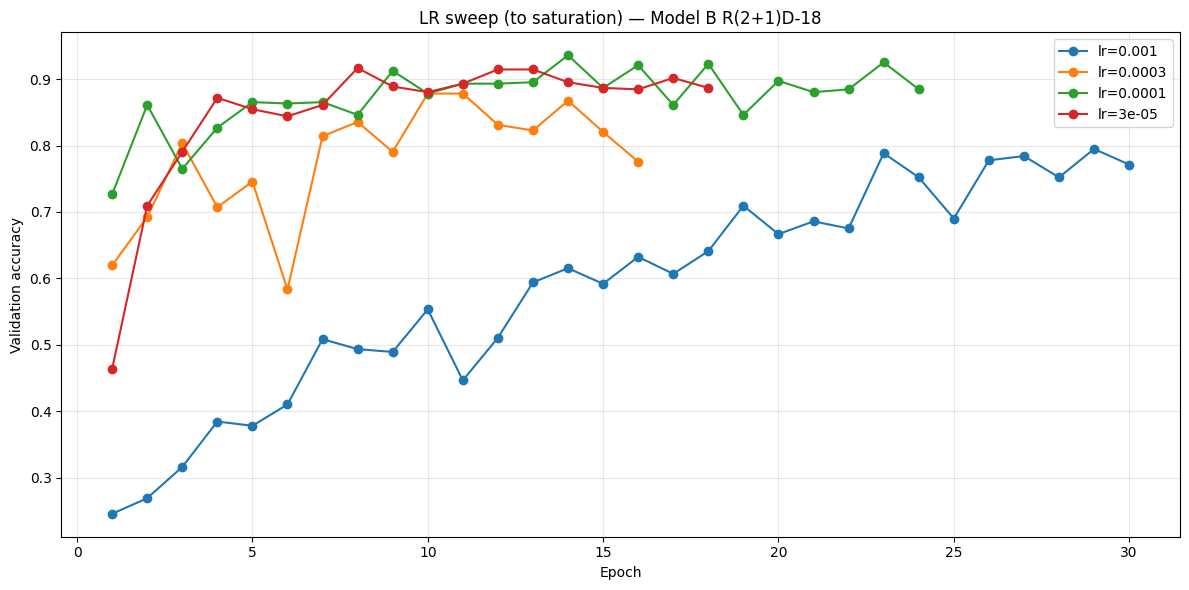

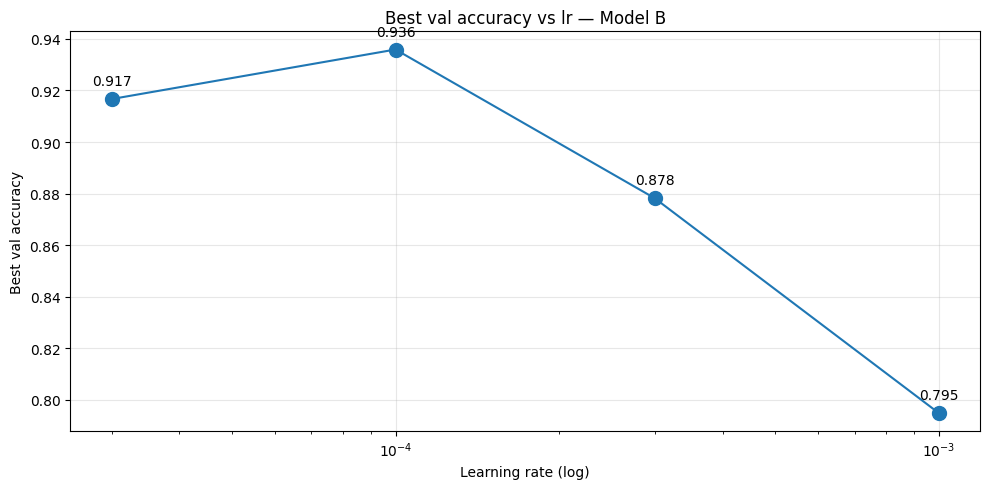


Best lr: 0.0001  (val acc 0.936)
  lr=0.0001   best val acc 0.936
  lr=3e-05    best val acc 0.917
  lr=0.0003   best val acc 0.878
  lr=0.001    best val acc 0.795


In [ ]:
plt.figure(figsize=(12, 6))
for lr, h in sweep_histories.items():
    plt.plot(range(1, len(h['val_acc']) + 1), h['val_acc'], marker='o', label=f"lr={lr}")
plt.xlabel('Epoch'); plt.ylabel('Validation accuracy')
plt.title('LR sweep (to saturation) - Model B R(2+1)D-18'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/kaggle/working/lr_sweep_curves_modelB.png", dpi=150, bbox_inches='tight')
plt.show()

best_per_lr = {lr: max(h['val_acc']) for lr, h in sweep_histories.items()}
plt.figure(figsize=(10, 5))
plt.semilogx(list(best_per_lr.keys()), list(best_per_lr.values()), marker='o', markersize=10)
for lr, v in best_per_lr.items():
    plt.annotate(f"{v:.3f}", (lr, v), textcoords="offset points", xytext=(0, 10), ha='center')
plt.xlabel('Learning rate (log)'); plt.ylabel('Best val accuracy')
plt.title('Best val accuracy vs lr - Model B'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/kaggle/working/lr_sweep_best_modelB.png", dpi=150, bbox_inches='tight')
plt.show()

best_lr_b = max(best_per_lr, key=best_per_lr.get)
print(f"\nBest lr: {best_lr_b}  (val acc {best_per_lr[best_lr_b]:.3f})")
for lr, v in sorted(best_per_lr.items(), key=lambda x: -x[1]):
    print(f"  lr={lr:<8} best val acc {v:.3f}")

## Step 7 - Final training with best lr, to saturation

[final] epoch  1/40 | train 1.826/0.432 | val 0.910/0.712 | 351s
[final] epoch  2/40 | train 0.810/0.775 | val 0.565/0.814 | 350s
[final] epoch  3/40 | train 0.518/0.857 | val 0.552/0.823 | 351s
[final] epoch  4/40 | train 0.429/0.883 | val 0.487/0.848 | 351s
[final] epoch  5/40 | train 0.340/0.902 | val 0.623/0.791 | 351s
[final] epoch  6/40 | train 0.271/0.922 | val 0.551/0.870 | 350s
[final] epoch  7/40 | train 0.227/0.933 | val 0.482/0.891 | 350s
[final] epoch  8/40 | train 0.240/0.934 | val 0.506/0.895 | 350s
[final] epoch  9/40 | train 0.190/0.944 | val 0.498/0.878 | 350s
[final] epoch 10/40 | train 0.140/0.960 | val 0.519/0.895 | 351s
[final] epoch 11/40 | train 0.123/0.968 | val 0.507/0.887 | 351s
[final] epoch 12/40 | train 0.173/0.958 | val 0.414/0.900 | 350s
[final] epoch 13/40 | train 0.146/0.952 | val 0.527/0.863 | 351s
[final] epoch 14/40 | train 0.127/0.963 | val 0.463/0.889 | 351s
[final] epoch 15/40 | train 0.126/0.967 | val 0.598/0.844 | 350s
[final] epoch 16/40 | tra

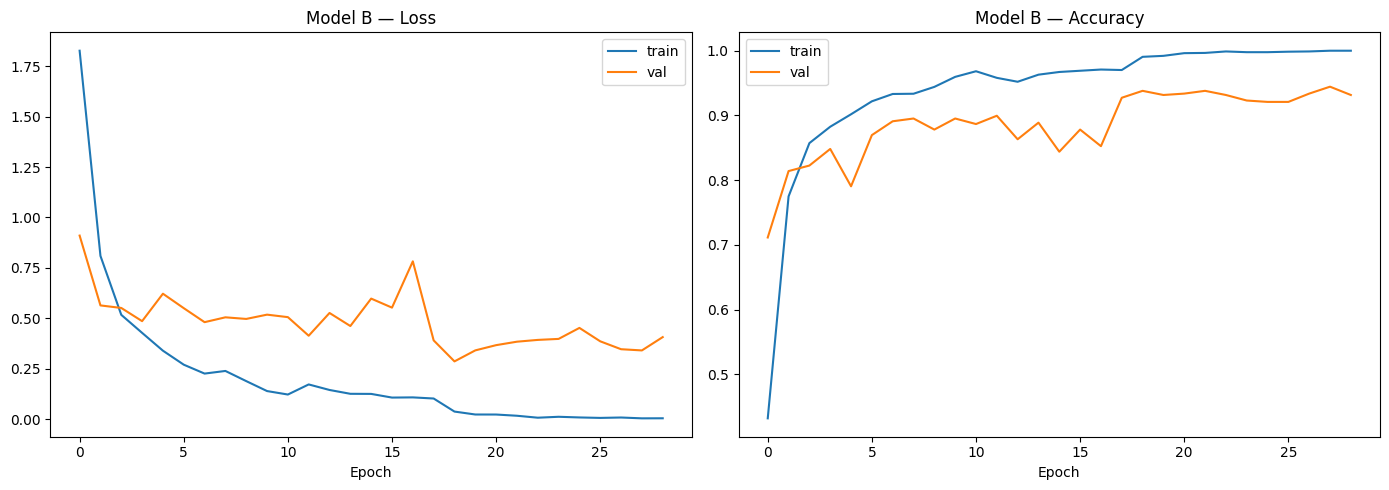

In [ ]:
torch.manual_seed(42)
model_b = build_r2plus1d(num_classes=NUM_CLASSES).to(DEVICE)
history_b = train_model(model_b, epochs=40, lr=best_lr_b, patience=10,
                        use_scheduler=True,
                        ckpt_path="/kaggle/working/best_r2plus1d.pth",
                        tag="[final]")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_b['train_loss'], label='train'); axes[0].plot(history_b['val_loss'], label='val')
axes[0].set_title('Model B - Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history_b['train_acc'], label='train'); axes[1].plot(history_b['val_acc'], label='val')
axes[1].set_title('Model B - Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.savefig("/kaggle/working/history_r2plus1d.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 8 - Evaluate on the test set

Accuracy: 0.9410  F1_w: 0.9411  F1_m: 0.9184  Top3: 0.9882  Top5: 0.9955

               precision    recall  f1-score   support

    Point-1f       0.97      0.98      0.98       265
    Point-2f       0.99      0.97      0.98       264
    Click-1f       0.86      0.92      0.89        52
    Click-2f       0.84      0.83      0.83        52
    Throw-up       0.96      0.92      0.94        52
  Throw-down       0.98      0.98      0.98        52
  Throw-left       1.00      0.94      0.97        52
 Throw-right       0.91      0.96      0.93        52
  Open-twice       0.96      0.94      0.95        52
 DblClick-1f       0.90      0.90      0.90        52
 DblClick-2f       0.86      0.85      0.85        52
     Zoom-in       0.85      0.96      0.90        52
    Zoom-out       0.84      0.81      0.82        52

    accuracy                           0.94      1101
   macro avg       0.92      0.92      0.92      1101
weighted avg       0.94      0.94      0.94      1101



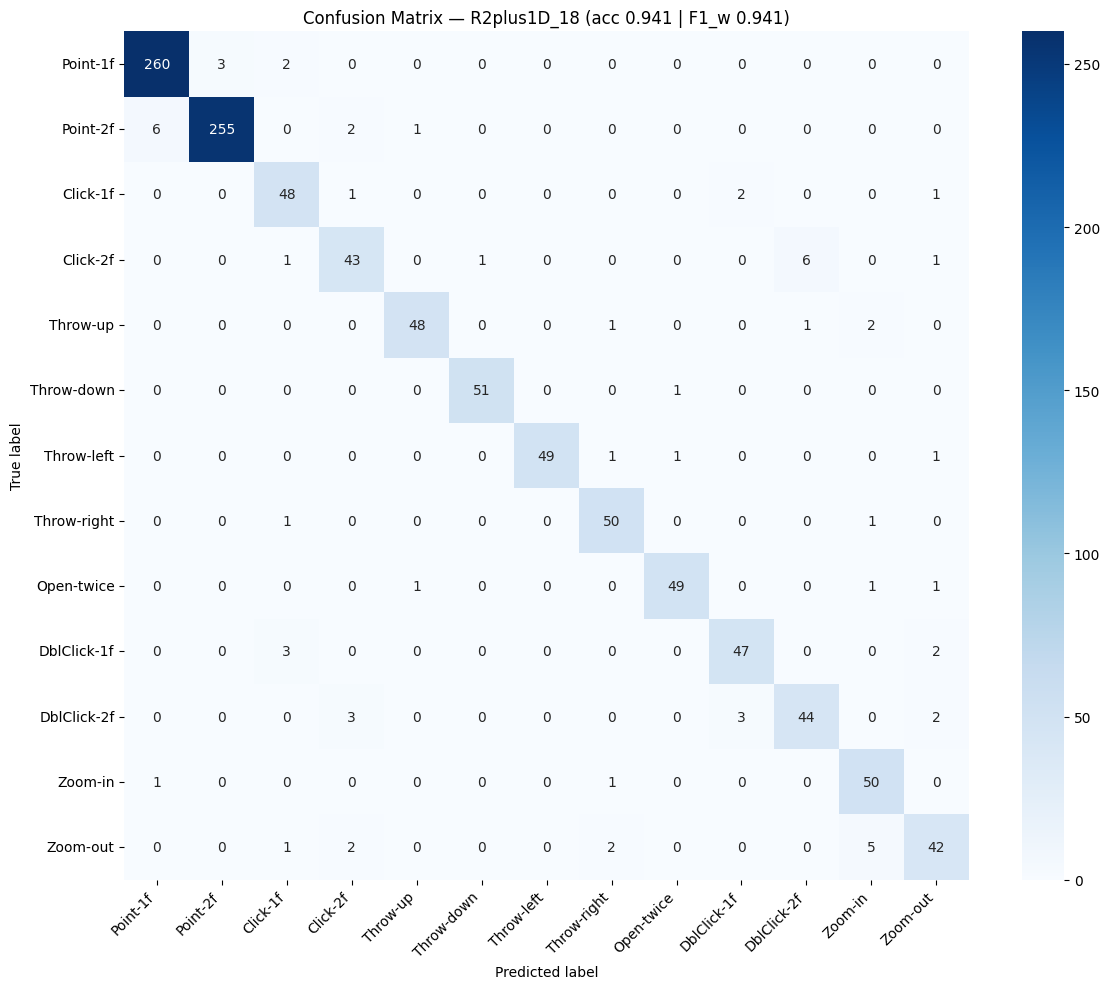

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, top_k_accuracy_score)
import seaborn as sns

@torch.no_grad()
def predict(model, loader):
    model.eval()
    yt, yp, ypr = [], [], []
    for x, y in loader:
        x = x.to(DEVICE)
        prob = torch.softmax(model(x), dim=1).cpu().numpy()
        ypr.append(prob); yp.append(prob.argmax(1)); yt.append(y.numpy())
    return np.concatenate(yt), np.concatenate(yp), np.concatenate(ypr)

y_true, y_pred, y_prob = predict(model_b, test_loader)

acc = accuracy_score(y_true, y_pred)
f1_w = f1_score(y_true, y_pred, average='weighted')
f1_m = f1_score(y_true, y_pred, average='macro')
top3 = top_k_accuracy_score(y_true, y_prob, k=3)
top5 = top_k_accuracy_score(y_true, y_prob, k=5)
print(f"Accuracy: {acc:.4f}  F1_w: {f1_w:.4f}  F1_m: {f1_m:.4f}  Top3: {top3:.4f}  Top5: {top5:.4f}")
print("\n", classification_report(y_true, y_pred, target_names=GESTURE_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES)
plt.title(f'Confusion Matrix - R2plus1D_18 (acc {acc:.3f} | F1_w {f1_w:.3f})')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig("/kaggle/working/confusion_R2plus1D_18.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 9 - Save results (download from Kaggle "Output" tab)

In [ ]:
import json

results = {
    'model': 'R2plus1D_18',
    'approach': 'raw video clip (R(2+1)D-18, pretrained Kinetics-400)',
    'accuracy': float(acc), 'f1_weighted': float(f1_w), 'f1_macro': float(f1_m),
    'top3_accuracy': float(top3), 'top5_accuracy': float(top5),
    'best_lr': float(best_lr_b),
    'config': {'architecture': 'R(2+1)D-18 pretrained', 'batch_size': BATCH_SIZE,
               'optimizer': 'Adam', 'dropout': 0.5, 'n_frames': 16, 'resolution': 112,
               'sweep_epochs': SWEEP_EPOCHS, 'final_epochs_max': 40},
}
with open("/kaggle/working/r2plus1d_results.json", "w") as f:
    json.dump(results, f, indent=2)

np.savez("/kaggle/working/predictions_modelB.npz",
         y_true=y_true, y_pred=y_pred, y_prob=y_prob)

print(json.dumps(results, indent=2))
print("\nSaved to /kaggle/working/ - download from the Output tab:")
print("  r2plus1d_results.json, predictions_modelB.npz, best_r2plus1d.pth,")
print("  confusion_R2plus1D_18.png, history_r2plus1d.png,")
print("  lr_sweep_curves_modelB.png, lr_sweep_best_modelB.png")

# List everything in working so you can confirm before saving the version
print("\nFiles in /kaggle/working/:")
for f in sorted(os.listdir("/kaggle/working")):
    print(f"  {f}  ({os.path.getsize(f'/kaggle/working/{f}')/1e6:.1f} MB)")

{
  "model": "R2plus1D_18",
  "approach": "raw video clip (R(2+1)D-18, pretrained Kinetics-400)",
  "accuracy": 0.9409627611262489,
  "f1_weighted": 0.9411092920620785,
  "f1_macro": 0.9184014867706137,
  "top3_accuracy": 0.9881925522252498,
  "top5_accuracy": 0.9954586739327884,
  "best_lr": 0.0001,
  "config": {
    "architecture": "R(2+1)D-18 pretrained",
    "batch_size": 16,
    "optimizer": "Adam",
    "dropout": 0.5,
    "n_frames": 16,
    "resolution": 112,
    "sweep_epochs": 30,
    "final_epochs_max": 40
  }
}

Saved to /kaggle/working/ — download from the Output tab:
  r2plus1d_results.json, predictions_modelB.npz, best_r2plus1d.pth,
  confusion_R2plus1D_18.png, history_r2plus1d.png,
  lr_sweep_curves_modelB.png, lr_sweep_best_modelB.png

Files in /kaggle/working/:
  __notebook__.ipynb  (0.4 MB)
  best_r2plus1d.pth  (125.4 MB)
  confusion_R2plus1D_18.png  (0.1 MB)
  history_r2plus1d.png  (0.1 MB)
  lr_sweep_best_modelB.png  (0.1 MB)
  lr_sweep_curves_modelB.png  (0.1 MB)
 